In [ ]:
# 📊 Electric Vehicle Market Analysis (US EV Dataset)

## 🔍 Project Overview
This project explores electric vehicle (EV) registrations across The US using data on vehicle models, types, electric ranges, and registration trends over time. The aim is to analyze current trends and forecast the EV market growth.

## 🧹 Data Cleaning
- Removed null values
- Selected relevant columns

## 📈 Exploratory Data Analysis (EDA)
- Registrations by year
- EV market share by manufacturer
- Top counties and cities for EV adoption
- EV types and popular models
- Trends in electric range over time

## 🔮 Forecasting
- Applied exponential growth modeling using `curve_fit` from `scipy`
- Forecasted EV registrations from 2024 to 2029

## 📌 Key Insights
- Tesla dominates the EV space
- Electric range has consistently increased over the years
- Registrations are rapidly growing, especially after 2018
- Los Angeles and San Diego counties lead in adoption

## 🚀 Forecasted Growth
The EV market is expected to grow significantly in the next 5 years, assuming current trends continue.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ev_data = pd.read_csv('/content/Electric_Vehicle_Population_Data.csv')
ev_data.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,37.0,125701579.0,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,244285107.0,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270.0,0.0,36.0,156773144.0,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210.0,0.0,5.0,165103011.0,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,23.0,205138552.0,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [ ]:
ev_data.shape

(8691, 17)

In [ ]:
nulls = ev_data.isnull().sum()
nulls

,0
VIN (1-10),0
County,0
City,0
State,0
Postal Code,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [ ]:
null_rows = ev_data[ev_data.isnull().any(axis=1)]
print(null_rows)

       VIN (1-10) County       City State  Postal Code  Model Year   Make  \
21790  5YJSA1E24L   King  Shoreline    WA        98177        2020  TESLA   

         Model           Electric Vehicle Type  \
21790  MODEL S  Battery Electric Vehicle (BEV)   

      Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
21790            Clean Alternative Fuel Vehicle Eligibl             NaN   

       Base MSRP  Legislative District  DOL Vehicle ID Vehicle Location  \
21790        NaN                   NaN             NaN              NaN   

      Electric Utility  2020 Census Tract  
21790              NaN                NaN  


In [ ]:
ev_cleaned = ev_data.dropna()
ev_cleaned.head()
ev_cleaned.shape

(8690, 17)

(array([1995., 2000., 2005., 2010., 2015., 2020., 2025., 2030.]),
 [Text(1995.0, 0, '1995'),
  Text(2000.0, 0, '2000'),
  Text(2005.0, 0, '2005'),
  Text(2010.0, 0, '2010'),
  Text(2015.0, 0, '2015'),
  Text(2020.0, 0, '2020'),
  Text(2025.0, 0, '2025'),
  Text(2030.0, 0, '2030')])

<Figure size 600x500 with 0 Axes>

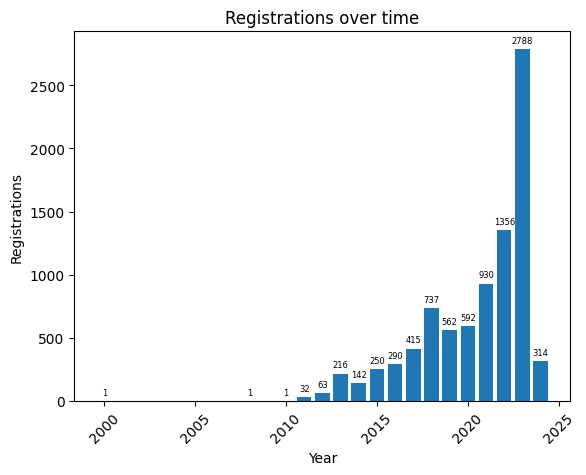

In [ ]:
#Counting registration per year
reg_per_year = ev_cleaned['Model Year'].value_counts().sort_index()
plt.figure(figsize=(6,5))
fig, ax = plt.subplots()
bar_reg = ax.bar(reg_per_year.index,reg_per_year.values)
ax.bar_label(bar_reg, padding=3, fontsize=6)
plt.title("Registrations over time")
plt.xlabel("Year")
plt.ylabel("Registrations")
plt.xticks(rotation=45)

<Figure size 1200x600 with 0 Axes>

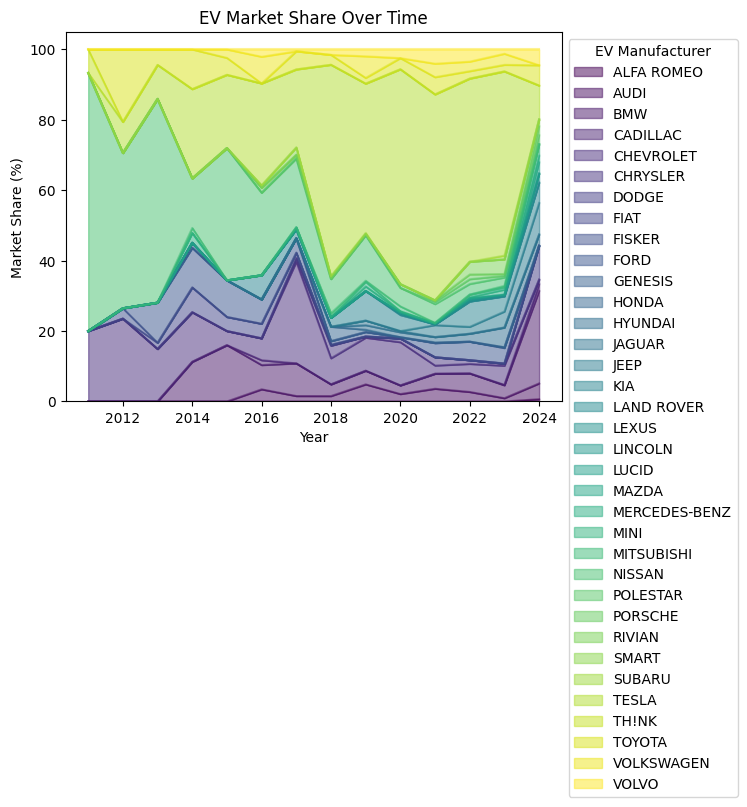

In [ ]:
#Market Share Analysis
ev_market_share = ev_cleaned.groupby(['Model Year', 'Make']).size().unstack().fillna(0)
ev_market_share_percentage = ev_market_share.div(ev_market_share.sum(axis=1), axis=0) * 100
# ev_top = ev_market_share_percentage.head(10)
# ev_percentage = ev_market_share_percentage.loc[ev_market_share_percentage.index.isin(ev_top)]
plt.figure(figsize=(12, 6))
ev_market_share_percentage.plot(kind='area', colormap='viridis', alpha=0.5)
#ev_market_share_percentage.plot(kind='bar',stacked = True, colormap='viridis', alpha=0.5)
plt.title('EV Market Share Over Time')
plt.xlabel('Year')
plt.ylabel('Market Share (%)')
plt.legend(title='EV Manufacturer', bbox_to_anchor=(1,1),loc='upper left')
plt.show()

In [ ]:
#Distribution at county level
ev_county = ev_cleaned['County'].value_counts()
top_counties = ev_county.head(3).index
print(top_counties)

Index(['King', 'Clark', 'Kitsap'], dtype='object', name='County')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Seattle'),
  Text(1, 0, 'Bellevue'),
  Text(2, 0, 'Kirkland'),
  Text(3, 0, 'Vancouver'),
  Text(4, 0, 'Redmond'),
  Text(5, 0, 'Kent'),
  Text(6, 0, 'Renton'),
  Text(7, 0, 'Sammamish'),
  Text(8, 0, 'Shoreline'),
  Text(9, 0, 'Tukwila')])

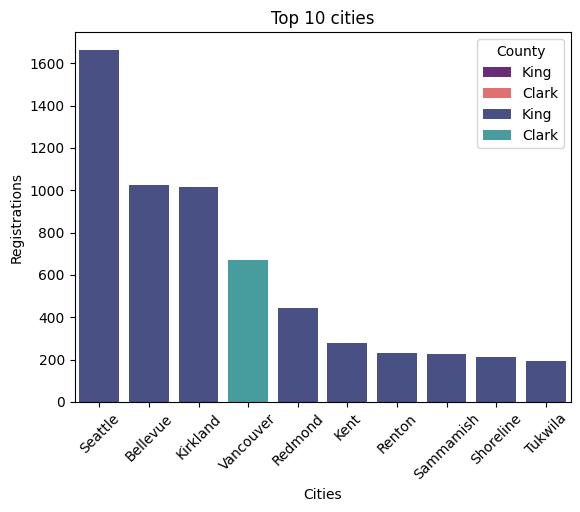

In [ ]:
#Filtering out top counties and top cities in those counties
top_counties_data = ev_cleaned[ev_cleaned['County'].isin(top_counties)]
county_distribution = top_counties_data.groupby(['County','City']).size().sort_values(ascending=False).reset_index(name="No. of vehicles")
top_cities = county_distribution.head(10)
#top_cities = ev_cleaned.groupby(['County','City']).size().sort_values(ascending=False).reset_index(name='Regisrations').head(10)

#Plotting a bar graph to visualize cities with highest vehicle registration
sns.barplot(x='City',y='No. of vehicles',data=top_cities,hue='County',palette='magma')
plt.title('Top 10 cities')
plt.xlabel('Cities')
plt.ylabel('Registartions')
plt.xticks(rotation=45)

#Plotting a bar to visualize cities with the highest vehicle registration
sns.barplot(x='City',y='No. of vehicles',data=top_cities,hue='County',palette='mako')
plt.title('Top 10 cities')
plt.xlabel('Cities')
plt.ylabel('Registrations')
plt.xticks(rotation=45)

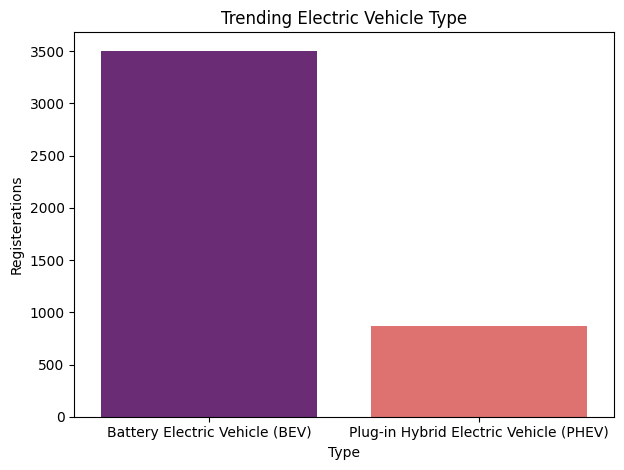

In [ ]:
#Analysing which electric vehicle type is used more
ev_type = ev_cleaned.groupby(['Electric Vehicle Type']).size().reset_index(name='Vehicles Registered')
ev_type
sns.barplot(x='Electric Vehicle Type',y='Vehicles Registered',data=ev_type,palette='magma',hue='Electric Vehicle Type')
plt.title('Trending Electric Vehicle Type')
plt.xlabel('Type')
plt.ylabel('Registerations')
plt.tight_layout()
plt.show()

<ipython-input-8-953cbe34affd>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Registered',y='Make',data=ev_make,palette='mako')


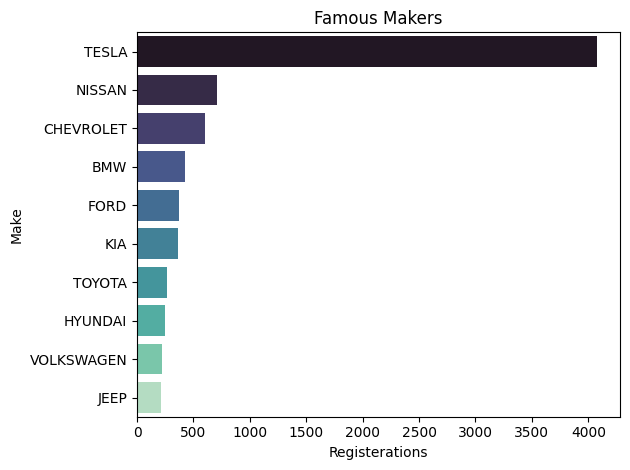

In [ ]:
#Analysing which manufacturers are the most famous
ev_make = ev_cleaned.groupby(['Make']).size().sort_values(ascending=False).reset_index(name='Registered').head(10)

sns.barplot(x='Registered',y='Make',data=ev_make,palette='mako')
plt.title('Famous Makers')
plt.xlabel('Registerations')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

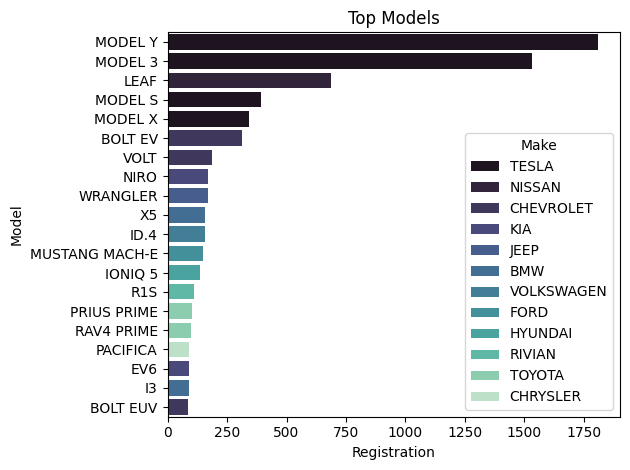

In [ ]:
#Top models for the top manufacturers

ev_make_model = ev_cleaned.groupby(['Make','Model']).size().sort_values(ascending=False).reset_index(name='Registrations').head(20)

sns.barplot(x='Registrations',y='Model',hue='Make',data=ev_make_model,palette='mako')
plt.title('Top Models')
plt.xlabel('Registration')
plt.ylabel('Model')
plt.tight_layout()
plt.show

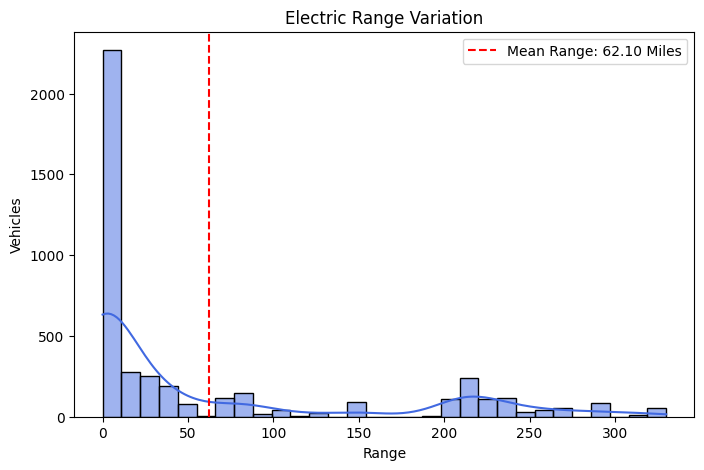

In [ ]:
#Analysing the variation in Electric Range
plt.figure(figsize=(8,5))
sns.histplot(ev_cleaned['Electric Range'],bins=30,color='royalblue',kde=True)
plt.title('Electric Range Variation')
plt.xlabel('Range')
plt.ylabel('Vehicles')
plt.axvline(ev_cleaned['Electric Range'].mean(),color='red',linestyle='--',label=f'Mean Range: {ev_cleaned["Electric Range"].mean():.2f} Miles')
plt.legend()
plt.show()

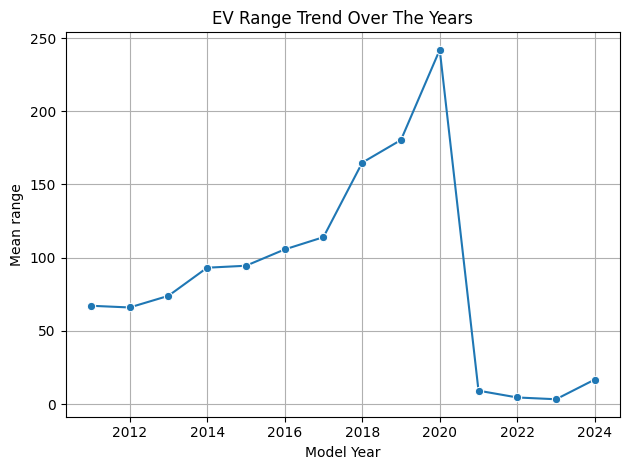

In [ ]:
#Analysing Range advancement based on model years
ev_ranges = ev_cleaned.groupby('Model Year')['Electric Range'].mean().reset_index(name='Mean Range').sort_values(['Model Year'],ascending=True)
ev_ranges
sns.lineplot(y='Mean Range',x='Model Year',marker='o',data=ev_ranges)
plt.title('EV Range Trend Over The Years')
plt.ylabel('Mean range')
plt.xlabel('Model Year')
plt.tight_layout()
plt.grid(True)
plt.show()

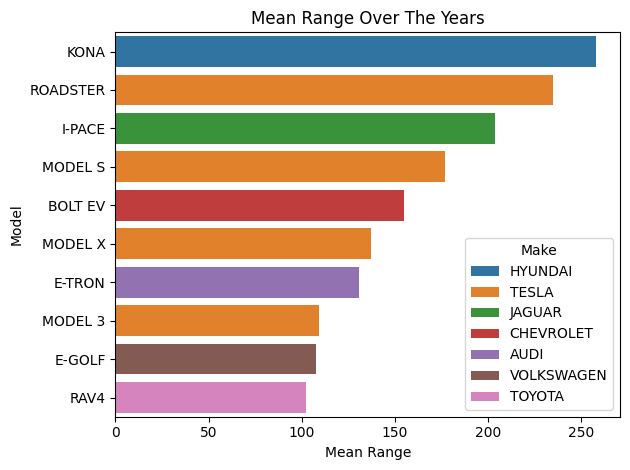

In [ ]:
#Analysing electric ranges for top models
range_top_model = ev_cleaned.groupby(['Make','Model'])['Electric Range'].mean().sort_values(ascending=False).reset_index().head(10)

sns.barplot(x='Electric Range',y='Model',hue='Make',data=range_top_model)
plt.title('Mean Range Over The Years')
plt.xlabel('Mean Range')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

{np.int64(2024): np.float64(3744.3864675664922), np.int64(2025): np.float64(5570.6723974629995), np.int64(2026): np.float64(8287.71047771262), np.int64(2027): np.float64(12329.955894313365), np.int64(2028): np.float64(18343.764875057725), np.int64(2029): np.float64(27290.747239947068)}


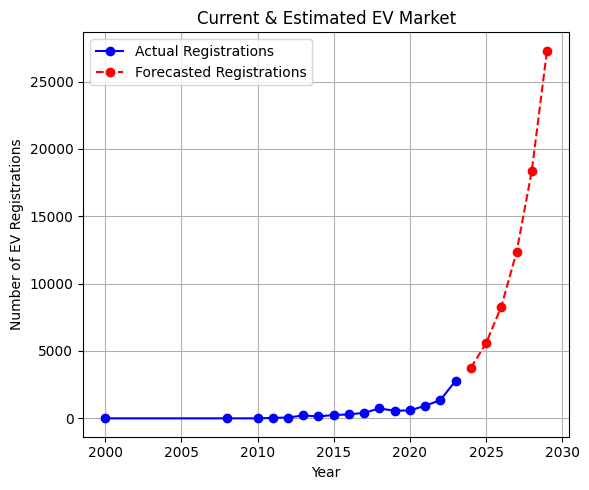

In [ ]:
#Forecasting for the following 5 years based on historic data

from scipy.optimize import curve_fit
import numpy as np

filtered_years = reg_per_year[reg_per_year.index <= 2023]

def exp_growth(x, a, b):
    return a * np.exp(b * x)

x_data = filtered_years.index - filtered_years.index.min()
y_data = filtered_years.values

params, covariance = curve_fit(exp_growth, x_data, y_data)

forecast_years = np.arange(2024, 2024 + 6) - filtered_years.index.min()
forecasted_values = exp_growth(forecast_years, *params)

forecasted_evs = dict(zip(forecast_years + filtered_years.index.min(), forecasted_values))

print(forecasted_evs)
years = np.arange(filtered_years.index. min(), 2029 + 1)
actual_years = filtered_years.index
forecast_years_full = np.arange(2024, 2029 + 1)

forecasted_years = np.arange(2024, 2024 + 10) = filtered_years.index.min()
actual_years =  filtered_years.min()
years = np.arange(filtered_year.index.min(), 2034+1)
plt.gifure(figsize(10,6))
plt.title('Hello World')
plt.xlabel('Whatsup')
plt.ylabel('yoo')
plt.tight_layout()
plt.legend()
foercasted_values = exp_growth(forecast_years, *params)
plt.grid(True)
plt.show()

forecasted_values_full = [forecasted_evs[year] for year in forecast_years_full]

forecasted_values_fully = [forecast_evs_fully[year] for year in forecast_years_fully]

actual_values = filtered_years.values
forecasted_values_full = [forecasted_evs[year] for year in forecast_years_full]

plt.figure(figsize=(6, 5))
plt.plot(actual_years, actual_values, 'bo-', label='Actual Registrations')
plt.plot(forecast_years_full, forecasted_values_full, 'ro--', label='Forecasted Registrations')
plt.title('Current & Estimated EV Market')
plt.xlabel('Year')
plt.ylabel('Number of EV Registrations')
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()